# (노트) 루나랜더

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [딥러닝]

In [7]:
#!pip install gym[Box_2D] Box2D box2d-py gym[box2d]

In [27]:
import gym
#from gym.wrappers import Monitor
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import base64, io

import numpy as np
from collections import deque, namedtuple

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display 
import glob

In [28]:
env = gym.make('LunarLander-v2')

In [49]:
class ReplayBuffer:
    def __init__(self):
        # 초기화 
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        
    def randomplay(self,env):
        # random action으로 게임 진행 -> 저장 
        state1 = env.reset()
        for t in range(1500):
            action = env.action_space.sample() 
            state2,reward, done, _ = env.step(action) 
            self.save(state1,action,reward,state2,done) 
            state1 = state2 
            if done:
                break
                
    def save(self, state, action, reward, next_state, done):
        self.states.append(state.tolist()) 
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state.tolist())
        self.dones.append(done)
        #self.n = self.n + 1 
        
        ## 최근 300개의 자료만 준비함. 
        if len(self.states)>5000:
            self._states = torch.tensor(self.states[-5000:])
            self._actions = torch.tensor(self.actions[-5000:]).reshape(-1,1)
            self._next_states = torch.tensor(self.next_states[-5000:])
            self._rewards = torch.tensor(self.rewards[-5000:]).reshape(-1,1)
            self._dones = torch.tensor(self.dones[-5000:]).to(torch.float).reshape(-1,1) 
        else:
            self._states = torch.tensor(self.states)
            self._actions = torch.tensor(self.actions).reshape(-1,1)
            self._next_states = torch.tensor(self.next_states)
            self._rewards = torch.tensor(self.rewards).reshape(-1,1)
            self._dones = torch.tensor(self.dones).to(torch.float).reshape(-1,1)
    
    def sample(self):
        _n = len(self._states)
        _index = np.random.choice(_n,128) # 128 is batch_size 
        states = torch.tensor(self._states)[_index]
        actions = torch.tensor(self._actions)[_index]
        rewards = torch.tensor(self._rewards)[_index]
        next_states = torch.tensor(self._next_states)[_index]
        dones = torch.tensor(self._dones)[_index]
        
        actions = torch.LongTensor(actions).reshape(-1,1)
        rewards = rewards.reshape(-1,1)
        dones = dones.to(torch.float).reshape(-1,1)
        return (states, actions, rewards, next_states, dones)
    
    def _repr_html_(self):
        html_str = """
        기록된 데이터 수: {} <br/> 
        """
        return html_str.format(len(self.states))

In [50]:
replaybuffer=ReplayBuffer()
replaybuffer

In [51]:
replaybuffer.randomplay(env)
replaybuffer

In [52]:
class Agent:
    def __init__(self):
        ## 기록관련 
        self.episoid = 0 # 게임횟수
        self.scores = [] # 점수 
        self.playtimes = [] # 게임1회당 클리어 타임
        self.lastreward = [] # 클리어여부? 
        
        ## 두뇌관련 
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=32),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=32, out_features=4)
        )     
        self.optimizer = optim.Adam(self.net.parameters(), lr=0.0001)
    
    def learn(self, replaybuffer):
        states, actions, rewards, next_states, dones = replaybuffer.sample() 
        yhat = self.net(states).gather(1, actions) # q(s_t,a_t)
        qvalue = self.net(next_states).detach().max(1)[0].reshape(-1,1) # max_a {q(s_{t+1},a)} 
        y = rewards + 0.99 * qvalue * (1 - dones) 
        yhat = self.net(states).gather(1, actions)
        self.loss = torch.mean((y-yhat)**2)
        self.optimizer.zero_grad()
        self.loss.backward()
        self.optimizer.step()            
            
    def act(self, state, eps=0.): 
        if np.random.rand() > eps: # 보통은 시키는대로 하지만.. 
            action = np.argmax(agent.net(torch.tensor(state)).detach())
        else: # 가끔 시키는대로 하기 싫을 때가 있음 
            action = np.random.randint(4) # 0,1,2,3 중에 아무행동을 랜덤으로 취한다! 
        return int(action)


In [53]:
n_episodes=2000
max_t=1000
eps_start=1
eps_end=0.01
eps_decay=0.995

In [54]:
agent = Agent()

In [55]:
replaybuffer = ReplayBuffer()

In [56]:
scores = []                        # list containing scores from each episode
scores_window = deque(maxlen=100)  # last 100 scores
#eps = eps_start                    # initialize epsilon
for i_episode in range(1, n_episodes+1):
    state = env.reset()
    score = 0
    for playtime in range(max_t):
        action = agent.act(state, 0.05)
        next_state, reward, done, _ = env.step(action)
        replaybuffer.save(state,action,reward,next_state,done)
        agent.learn(replaybuffer)
        state = next_state
        score += reward
        if done:
            break 
    scores_window.append(score)       # save most recent score
    scores.append(score)              # save most recent score
    #eps = max(eps_end, eps_decay*eps) # decrease epsilon
    
    print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)), end="")
    if i_episode % 100 == 0:
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)))
    if np.mean(scores_window)>=200.0:
        print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_window)))
        torch.save(agent.net.state_dict(), 'checkpoint.pth')
        break

/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:49: UserWarning: To copy construct from a tensor, it is recommended to use s

Episode 100	Average Score: -191.58
Episode 200	Average Score: -112.99
Episode 300	Average Score: -55.616
Episode 400	Average Score: -55.06
Episode 500	Average Score: -56.12
Episode 700	Average Score: -59.17
Episode 800	Average Score: -1.179
Episode 900	Average Score: -63.13
Episode 1000	Average Score: 21.62
Episode 1100	Average Score: 138.54
Episode 1400	Average Score: 181.14
Episode 1500	Average Score: 180.91
Episode 1531	Average Score: 200.11
Environment solved in 1431 episodes!	Average Score: 200.11


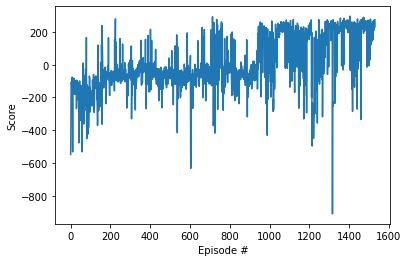

In [57]:
# plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()